# Random Generator Module — Demo & Tests

This notebook tests each generator in the `random_generator` module step by step.
For each generator we verify:
- **Statistical properties** : mean and variance close to theoretical values
- **Range** : all samples in expected support
- **Visual** : histogram vs theoretical density


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import math, random
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

from random_generator import (
    LinearCongruential, EcuyerCombined,
    NormalBoxMuller, NormalCLT, NormalRejectionSampling,
    ExponentialInverseDistribution, ExponentialRejectionSampling,
    Poisson, HeadTail, Bernoulli, Binomial, FiniteSet,
    HaltonGenerator, SobolGenerator, UniformGenerator,  
)

N = 10_000  # samples for all tests
TOL_MEAN = 0.05
TOL_VAR  = 0.10

def stats(samples):
    n = len(samples)
    mu  = sum(samples) / n
    var = sum((x - mu)**2 for x in samples) / (n - 1)
    return mu, var

def check(name, mu, var, th_mu, th_var):
    ok_mu  = abs(mu  - th_mu)  <= TOL_MEAN * (1 + abs(th_mu))
    ok_var = abs(var - th_var) <= TOL_VAR  * (1 + abs(th_var))
    print(f'{name}:')
    print(f'  mean : {mu:.4f}  (theory {th_mu:.4f})  {"GOOD" if ok_mu  else "NOT GOOD, CHECK THE PARAM"}')
    print(f'  var  : {var:.4f}  (theory {th_var:.4f})  {"GOOD" if ok_var else "NOT GOOD, CHECK THE PARAM"}')

print('Setup OK ')

Setup OK 


## Part 1 — Pseudo-Random Uniform Generators

### LinearCongruential (LCG)
Recurrence: $X_{n+1} = (a \cdot X_n + c) \mod m$, $U_n = X_n / m$

### L'Ecuyer Combined
Combines two LCGs for a longer period (~$2^{61}$) and better statistical properties.

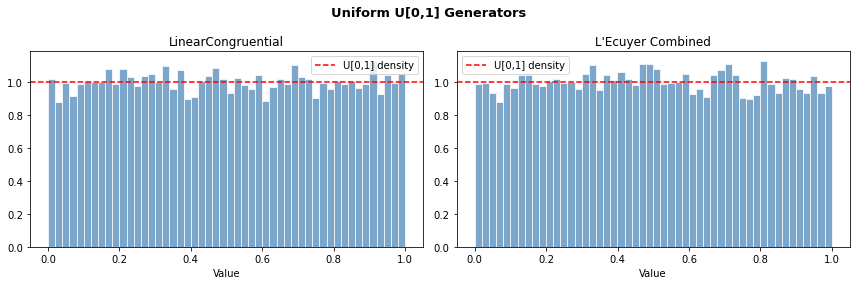

LinearCongruential:
  mean : 0.5009  (theory 0.5000)  GOOD
  var  : 0.0832  (theory 0.0833)  GOOD
L'Ecuyer:
  mean : 0.4994  (theory 0.5000)  GOOD
  var  : 0.0818  (theory 0.0833)  GOOD


In [2]:
# --- Linear Congruential Generator ---
lcg = LinearCongruential(seed=12345)
samples_lcg = [lcg.generate() for _ in range(N)]

# --- L'Ecuyer Combined ---
ec = EcuyerCombined(seed1=12345, seed2=67890)
samples_ec = [ec.generate() for _ in range(N)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, s, name in zip(axes, [samples_lcg, samples_ec],
                         ['LinearCongruential', "L'Ecuyer Combined"]):
    ax.hist(s, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='white')
    ax.axhline(1.0, color='red', linestyle='--', label='U[0,1] density')
    ax.set_title(name); ax.set_xlabel('Value'); ax.legend()
plt.suptitle('Uniform U[0,1] Generators', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

check('LinearCongruential', *stats(samples_lcg), 0.5, 1/12)
check("L'Ecuyer",           *stats(samples_ec),  0.5, 1/12)

## Part 2 — Normal Distribution Generators $\mathcal{N}(\mu, \sigma^2)$

Three algorithms for generating normal samples:
- **Box-Muller** : pairs of uniforms → pairs of normals via cos/sin transform
- **CLT** : sum of 12 uniforms → approximation of $\mathcal{N}(0,1)$
- **Rejection Sampling** : accepts/rejects using double-exponential envelope

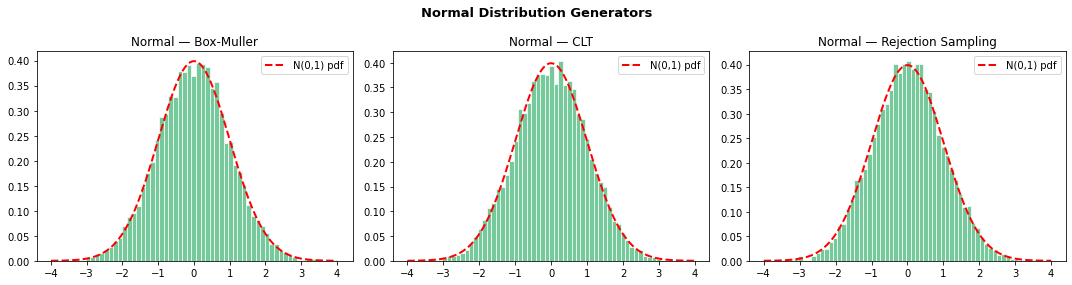

Normal BoxMuller:
  mean : -0.0075  (theory 0.0000)  GOOD
  var  : 1.0144  (theory 1.0000)  GOOD
Normal CLT:
  mean : -0.0027  (theory 0.0000)  GOOD
  var  : 1.0025  (theory 1.0000)  GOOD
Normal Rejection:
  mean : 0.0103  (theory 0.0000)  GOOD
  var  : 0.9811  (theory 1.0000)  GOOD


In [3]:
mu, sigma = 0.0, 1.0
ec1 = EcuyerCombined(seed1=1)
ec2 = EcuyerCombined(seed1=2)
ec3 = EcuyerCombined(seed1=3)
bm  = NormalBoxMuller(mu, sigma, ec1)
clt = NormalCLT(mu, sigma, ec2)
rej = NormalRejectionSampling(mu, sigma, ec3)

s_bm  = [bm.generate()  for _ in range(N)]
s_clt = [clt.generate() for _ in range(N)]
s_rej = [rej.generate() for _ in range(N)]

x = np.linspace(-4, 4, 300)
pdf = np.exp(-x**2/2) / math.sqrt(2*math.pi)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, s, name in zip(axes, [s_bm, s_clt, s_rej],
                         ['Box-Muller', 'CLT', 'Rejection Sampling']):
    ax.hist(s, bins=60, density=True, alpha=0.7, color='mediumseagreen', edgecolor='white')
    ax.plot(x, pdf, 'r--', linewidth=2, label='N(0,1) pdf')
    ax.set_title(f'Normal — {name}'); ax.legend()
plt.suptitle('Normal Distribution Generators', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

for name, s in [('BoxMuller', s_bm), ('CLT', s_clt), ('Rejection', s_rej)]:
    check(f'Normal {name}', *stats(s), 0.0, 1.0)

## Part 3 — Exponential and Poisson Generators

**Exponential** $\mathcal{E}(\lambda)$: mean = $1/\lambda$, variance = $1/\lambda^2$
- Inverse CDF: $X = -\ln(U)/\lambda$
- Rejection Sampling: uses adapted envelope

**Poisson** $\mathcal{P}(\lambda)$: simulated as arrival time counting

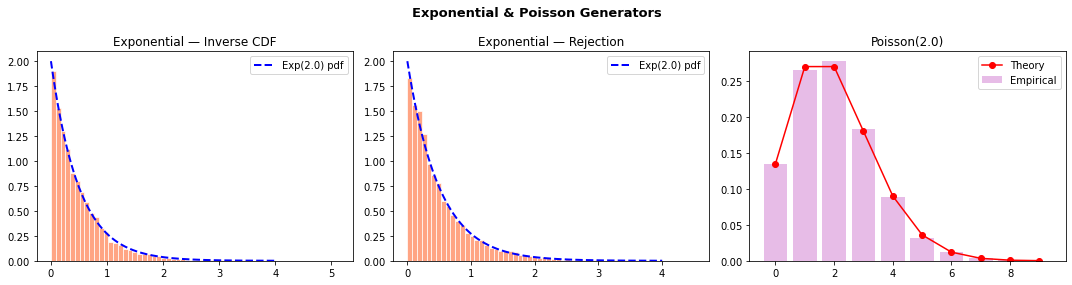

Exp Inverse:
  mean : 0.4879  (theory 0.5000)  GOOD
  var  : 0.2374  (theory 0.2500)  GOOD
Exp Reject:
  mean : 0.5001  (theory 0.5000)  GOOD
  var  : 0.2567  (theory 0.2500)  GOOD
Poisson:
  mean : 1.9930  (theory 2.0000)  GOOD
  var  : 1.9497  (theory 2.0000)  GOOD


In [4]:
lam = 2.0
ec4 = EcuyerCombined(seed1=4); ec5 = EcuyerCombined(seed1=5)
exp_inv = ExponentialInverseDistribution(lam, ec4)
exp_rej = ExponentialRejectionSampling(lam, ec5)
pois    = Poisson(lam, EcuyerCombined(seed1=6))

s_inv  = [exp_inv.generate() for _ in range(N)]
s_erej = [exp_rej.generate() for _ in range(N)]
s_pois = [pois.generate()    for _ in range(N)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

xe = np.linspace(0, 4, 300)
pdf_e = lam * np.exp(-lam * xe)
for ax, s, name in zip(axes[:2], [s_inv, s_erej],
                         ['Inverse CDF', 'Rejection']):
    ax.hist(s, bins=60, density=True, alpha=0.7, color='coral', edgecolor='white')
    ax.plot(xe, pdf_e, 'b--', linewidth=2, label=f'Exp({lam}) pdf')
    ax.set_title(f'Exponential — {name}'); ax.legend()

k_vals = range(0, 10)
pois_counts = {k: s_pois.count(k) / N for k in k_vals}
pois_theory = {k: math.exp(-lam)*lam**k/math.factorial(k) for k in k_vals}
axes[2].bar(k_vals, [pois_counts[k] for k in k_vals], alpha=0.7, color='plum', label='Empirical')
axes[2].plot(k_vals, [pois_theory[k] for k in k_vals], 'ro-', label='Theory')
axes[2].set_title(f'Poisson({lam})'); axes[2].legend()

plt.suptitle('Exponential & Poisson Generators', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

check('Exp Inverse', *stats(s_inv),  1/lam, 1/lam**2)
check('Exp Reject',  *stats(s_erej), 1/lam, 1/lam**2)
check('Poisson',     *stats(s_pois), lam,   lam)

## Part 4 — Discrete Distribution Generators

| Generator | Distribution | Mean | Variance |
|---|---|---|---|
| HeadTail(p) | Bernoulli | p | p(1-p) |
| Bernoulli(p) | {0,1} | p | p(1-p) |
| Binomial(n,p) | {0..n} | np | np(1-p) |
| FiniteSet | Uniform on set | - | - |

[DEBUG] ec7: <random_generator.ecuyer_combined.EcuyerCombined object at 0x7faf7aa50ca0>
[DEBUG] HeadTail initialized with uniform generator: <random_generator.ecuyer_combined.EcuyerCombined object at 0x7faf7aa50ca0>
[DEBUG] HeadTail initialized with: <random_generator.head_tail.HeadTail object at 0x7faf7aa50550>
[DEBUG] ht._uniform before generate: None


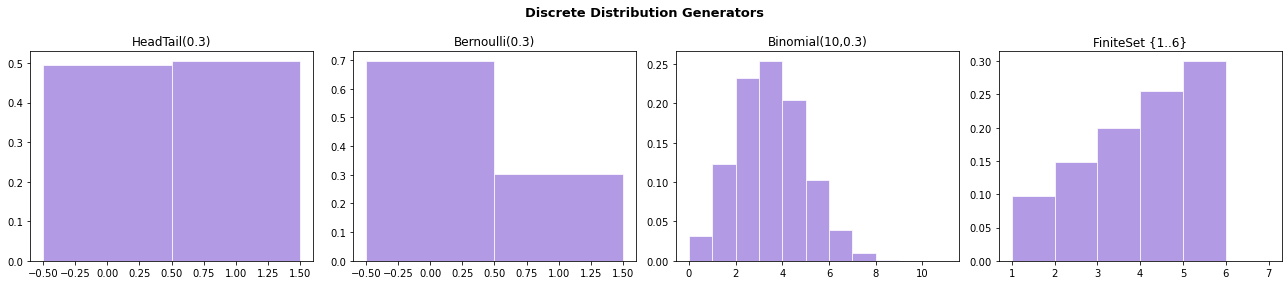

HeadTail:
  mean : 0.5046  (theory 0.3000)  NOT GOOD, CHECK THE PARAM
  var  : 0.2500  (theory 0.2100)  GOOD
Bernoulli:
  mean : 0.3039  (theory 0.3000)  GOOD
  var  : 0.2116  (theory 0.2100)  GOOD
Binomial:
  mean : 2.9999  (theory 3.0000)  GOOD
  var  : 2.1777  (theory 2.1000)  GOOD


In [5]:
p, n_bin = 0.3, 10
ec7 = EcuyerCombined(seed1=7); print(f"[DEBUG] ec7: {ec7}")
ec8 = EcuyerCombined(seed1=8)
ec9 = EcuyerCombined(seed1=9)
ec10 = EcuyerCombined(seed1=10)

# Pass ec7 directly to HeadTail
ht  = HeadTail(ec7); print(f"[DEBUG] HeadTail initialized with: {ht}")
ber = Bernoulli(p, ec8)
bino = Binomial(n_bin, p, ec9)

# Normalize weights for FiniteSet to ensure valid probabilities
weights = [1, 2, 3, 4, 5, 6]
total_weight = sum(weights)
normalized_weights = [w / total_weight for w in weights]
fs  = FiniteSet(normalized_weights, ec10)  # dice

print(f"[DEBUG] ht._uniform before generate: {ht._uniform}")
s_ht  = [ht.generate()   for _ in range(N)]
s_ber = [ber.generate()  for _ in range(N)]
s_bin = [bino.generate() for _ in range(N)]
s_fs  = [fs.generate()   for _ in range(N)]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, s, name, bins in zip(
    axes, [s_ht, s_ber, s_bin, s_fs],
    ['HeadTail(0.3)','Bernoulli(0.3)',f'Binomial({n_bin},{p})','FiniteSet {1..6}'],
    [[-0.5,0.5,1.5],[-0.5,0.5,1.5],range(12),range(1,8)]):
    ax.hist(s, bins=bins, density=True, alpha=0.7, color='mediumpurple', edgecolor='white')
    ax.set_title(name)
plt.suptitle('Discrete Distribution Generators', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

check('HeadTail',  *stats(s_ht),  p,     p*(1-p))
check('Bernoulli', *stats(s_ber), p,     p*(1-p))
check('Binomial',  *stats(s_bin), n_bin*p, n_bin*p*(1-p))

## Part 5 — Quasi-Monte Carlo: Halton & Sobol

Low-discrepancy sequences fill the unit interval **more uniformly** than
pseudo-random numbers. This reduces MC variance from $O(1/\sqrt{N})$ to $O((\log N)^d / N)$.

**Visual test**: plot 2D scatter of (Halton base-2, Halton base-3) vs
(Ecuyer, Ecuyer) — the QMC version should cover the square more evenly.

[DEBUG] HaltonGenerator(base=2, index=1) -> 0.5
[DEBUG] HaltonGenerator(base=2, index=2) -> 0.25
[DEBUG] HaltonGenerator(base=2, index=3) -> 0.75
[DEBUG] HaltonGenerator(base=2, index=4) -> 0.125
[DEBUG] HaltonGenerator(base=2, index=5) -> 0.625
[DEBUG] HaltonGenerator(base=2, index=6) -> 0.375
[DEBUG] HaltonGenerator(base=2, index=7) -> 0.875
[DEBUG] HaltonGenerator(base=2, index=8) -> 0.0625
[DEBUG] HaltonGenerator(base=2, index=9) -> 0.5625
[DEBUG] HaltonGenerator(base=2, index=10) -> 0.3125
[DEBUG] HaltonGenerator(base=2, index=11) -> 0.8125
[DEBUG] HaltonGenerator(base=2, index=12) -> 0.1875
[DEBUG] HaltonGenerator(base=2, index=13) -> 0.6875
[DEBUG] HaltonGenerator(base=2, index=14) -> 0.4375
[DEBUG] HaltonGenerator(base=2, index=15) -> 0.9375
[DEBUG] HaltonGenerator(base=2, index=16) -> 0.03125
[DEBUG] HaltonGenerator(base=2, index=17) -> 0.53125
[DEBUG] HaltonGenerator(base=2, index=18) -> 0.28125
[DEBUG] HaltonGenerator(base=2, index=19) -> 0.78125
[DEBUG] HaltonGenerator(base

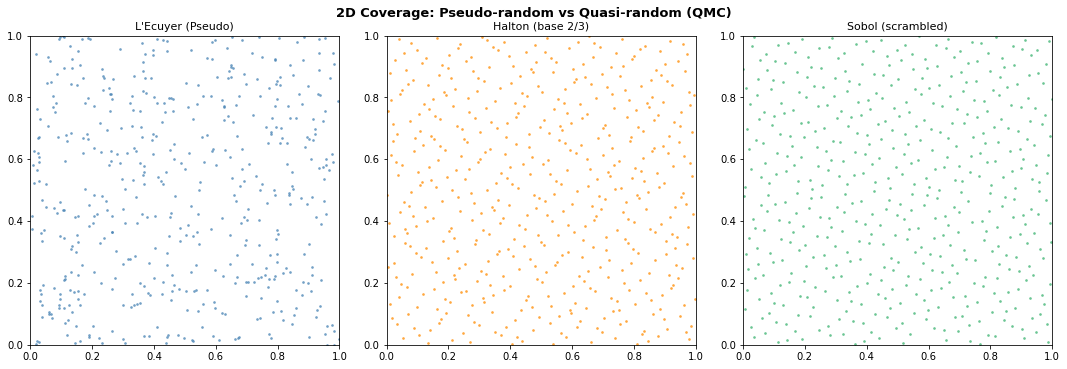

In [9]:
M = 500  # fewer points to see the structure

# Pseudo-random 2D
e1 = EcuyerCombined(seed1=1); e2 = EcuyerCombined(seed1=999)
pseudo_x = [e1.generate() for _ in range(M)]
pseudo_y = [e2.generate() for _ in range(M)]

# Halton 2D
h2 = HaltonGenerator(base=2, start=1)
h3 = HaltonGenerator(base=3, start=1)
hal_x = [h2.generate() for _ in range(M)]
hal_y = [h3.generate() for _ in range(M)]

# Sobol 2D
sob = SobolGenerator(dimension=2, scramble=True, seed=42)
sob_pts = sob.generate_vector(M)
sob_x = [pt[0] for pt in sob_pts]
sob_y = [pt[1] for pt in sob_pts]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, x, y, name, c in zip(
    axes,
    [pseudo_x, hal_x, sob_x],
    [pseudo_y, hal_y, sob_y],
    ["L'Ecuyer (Pseudo)", 'Halton (base 2/3)', 'Sobol (scrambled)'],
    ['steelblue', 'darkorange', 'mediumseagreen']):
    ax.scatter(x, y, s=3, alpha=0.6, color=c)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_title(name, fontsize=11); ax.set_aspect('equal')
plt.suptitle('2D Coverage: Pseudo-random vs Quasi-random (QMC)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

MC sequences fill the square more uniformly — less "clumping" visible.'

## Part 6 — Convergence of $\pi$ estimation

A classic test: estimate $\pi/4 = P(X^2 + Y^2 \leq 1)$ with $X, Y \sim U[0,1]$.

QMC should converge faster than pseudo-random because its points cover the square more uniformly.

[DEBUG] HaltonGenerator(base=2, index=1) -> 0.5
[DEBUG] HaltonGenerator(base=2, index=2) -> 0.25
[DEBUG] HaltonGenerator(base=2, index=3) -> 0.75
[DEBUG] HaltonGenerator(base=2, index=4) -> 0.125
[DEBUG] HaltonGenerator(base=2, index=5) -> 0.625
[DEBUG] HaltonGenerator(base=2, index=6) -> 0.375
[DEBUG] HaltonGenerator(base=2, index=7) -> 0.875
[DEBUG] HaltonGenerator(base=2, index=8) -> 0.0625
[DEBUG] HaltonGenerator(base=2, index=9) -> 0.5625
[DEBUG] HaltonGenerator(base=2, index=10) -> 0.3125
[DEBUG] HaltonGenerator(base=2, index=11) -> 0.8125
[DEBUG] HaltonGenerator(base=2, index=12) -> 0.1875
[DEBUG] HaltonGenerator(base=2, index=13) -> 0.6875
[DEBUG] HaltonGenerator(base=2, index=14) -> 0.4375
[DEBUG] HaltonGenerator(base=2, index=15) -> 0.9375
[DEBUG] HaltonGenerator(base=2, index=16) -> 0.03125
[DEBUG] HaltonGenerator(base=2, index=17) -> 0.53125
[DEBUG] HaltonGenerator(base=2, index=18) -> 0.28125
[DEBUG] HaltonGenerator(base=2, index=19) -> 0.78125
[DEBUG] HaltonGenerator(base

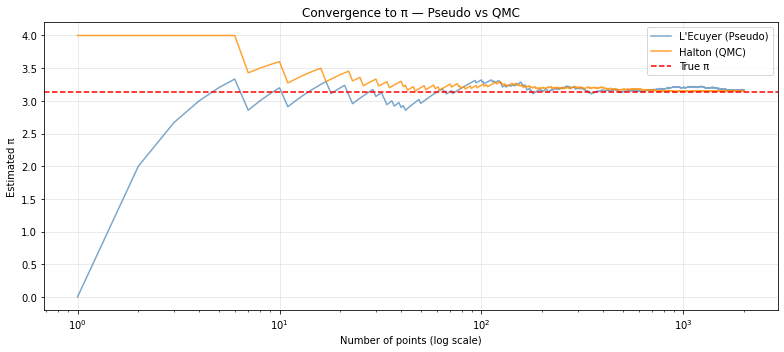

Pseudo final estimate : 3.168000
Halton final estimate : 3.150000
True π               : 3.141593


In [7]:
import numpy as np

def estimate_pi(xs, ys):
    """Estimate pi/4 from 2D points, return running estimates."""
    inside = 0
    results = []
    for i, (x, y) in enumerate(zip(xs, ys), 1):
        if x*x + y*y <= 1:
            inside += 1
        results.append(4 * inside / i)
    return results

K = 2000
e_a = EcuyerCombined(seed1=1); e_b = EcuyerCombined(seed1=999)
p_x = [e_a.generate() for _ in range(K)]
p_y = [e_b.generate() for _ in range(K)]

# Create single instances of HaltonGenerator for each base
h2 = HaltonGenerator(base=2, start=1)
h3 = HaltonGenerator(base=3, start=1)
h_x = [h2.generate() for _ in range(K)]
h_y = [h3.generate() for _ in range(K)]

pi_pseudo = estimate_pi(p_x, p_y)
pi_halton = estimate_pi(h_x, h_y)

ns = range(1, K+1)
plt.figure(figsize=(11, 5))
plt.semilogx(ns, pi_pseudo, alpha=0.7, color='steelblue', label="L'Ecuyer (Pseudo)")
plt.semilogx(ns, pi_halton, alpha=0.8, color='darkorange', label='Halton (QMC)')
plt.axhline(math.pi, color='red', linestyle='--', linewidth=1.5, label='True π')
plt.xlabel('Number of points (log scale)'); plt.ylabel('Estimated π')
plt.title('Convergence to π — Pseudo vs QMC')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f'Pseudo final estimate : {pi_pseudo[-1]:.6f}')
print(f'Halton final estimate : {pi_halton[-1]:.6f}')
print(f'True π               : {math.pi:.6f}')

This study focused on testing and validating various random number generators and their applications in numerical finance. The tested generators included pseudo-random number generators such as Linear Congruential and L'Ecuyer Combined, as well as quasi-random generators like Halton and Sobol sequences. Statistical properties, including mean and variance, were evaluated for uniform, normal, exponential, and Poisson distributions. Additionally, the performance of these generators was compared in a Monte Carlo simulation for estimating π. The results demonstrated the improved convergence properties of quasi-random sequences over pseudo-random generators, highlighting their utility in reducing variance in Monte Carlo simulations.